In [2]:
import numpy as np
import batman 
import matplotlib.pyplot  as plt

In [3]:
# let's start by wrapping batman in a function, which will come in handy later when we start doing MCMC inference.

def transit(time, limbdarkening_parameters, keplerian_parameters, planet_radius):

    u1, u2 = limbdarkening_parameters

    transit_time, period, semimajor_axis, inclination, eccentricity, argument_of_periastron = keplerian_parameters
    param_obj = batman.TransitParams()
    param_obj.t0 = transit_time                     
    param_obj.per = period                     
    param_obj.rp = planet_radius                 
    param_obj.a = semimajor_axis                       
    param_obj.inc = inclination                     
    param_obj.ecc = eccentricity                     
    param_obj.w = argument_of_periastron                       
    param_obj.u = [u1, u2]                
    param_obj.limb_dark = "quadratic"     

    return batman.TransitModel(param_obj, time, fac=0.01).light_curve(param_obj)

Text(0, 0.5, 'relative flux model')

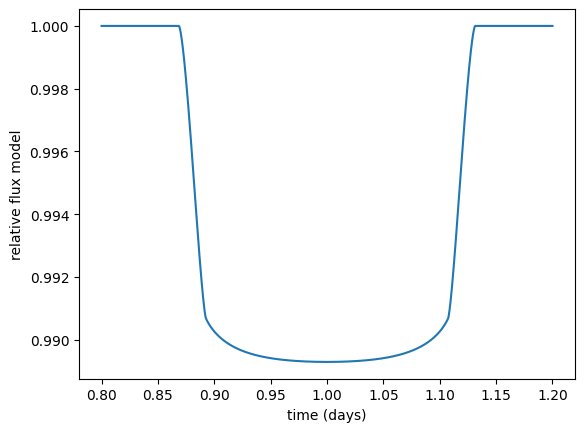

In [4]:
# check that the function works, and try some different combinations of parameters to see if the changing 
# shape of the transit lightcurve matches your intuition. 

# in particular try reducing or increasing the period and semimajor axis separately and at the same time. 
# notice that when you change the two in tandem the transit duration remains roughly constant. 

t = np.linspace(0.8, 1.2, 1000)

# quadratic limb-darkening paremeters
ld = [0.1, 0.2]

# center of transit time, period, semimajor axis, inclination, eccentricity, argument of periastron
k = [1.0, 15, 20, 90, 0.0, 0.0]

# planet radius 
r = 0.1

model = transit(t, ld, k, r)

plt.plot(t, model)
plt.xlabel('time (days)')
plt.ylabel('relative flux model')

[Text(0, 0.5, 'normalized intensity'), Text(0, 0.5, 'normalized intensity')]

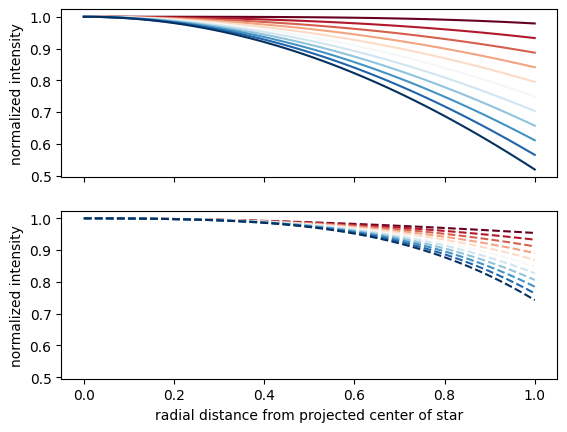

In [5]:
# the limb-darkening parameters dictate the radial intensity profile of the star. 
# let's look at how the intensity profile varies for different combinations of parameters 

b = np.linspace(0, 1)
mu = np.cos(b)

fig, axs = plt.subplots(2, 1, sharex=True, sharey=True)

u1 = np.linspace(0, 1, 11)
u2 = 0.1

ld_profile = np.array([1 - u1 * (1 - mu) - u2 * (1 - mu)**2 for u1 in u1])

[axs[0].plot(b, profile, color=plt.cm.RdBu(u1)) for profile, u1 in zip(ld_profile, u1)];

u1 = 0.1
u2 = np.linspace(0, 1, 11)

ld_profile = np.array([1 - u1 * (1 - mu) - u2 * (1 - mu)**2 for u2 in u2])

[axs[1].plot(b, profile, color=plt.cm.RdBu(u2), linestyle='--') for profile, u2 in zip(ld_profile, u2)];

axs[1].set_xlabel('radial distance from projected center of star')
[ax.set_ylabel('normalized intensity') for ax in axs]

Text(0, 0.5, 'time (integrations)')

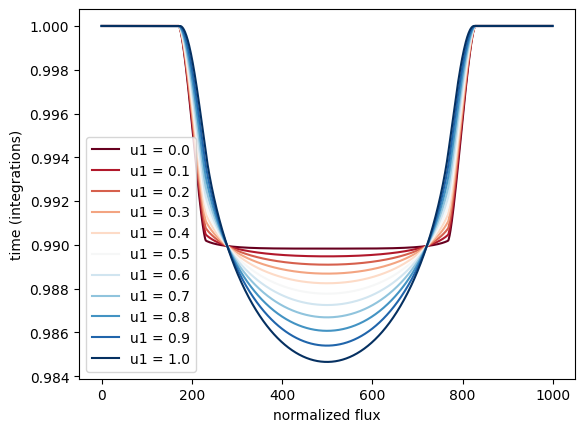

In [6]:
u1 = np.linspace(0, 1, 11)
u2 = 0.1
models = np.array([transit(t, (u1, u2), k, r) for u1 in u1])
[plt.plot(m, color=plt.cm.RdBu(u1), label='u1 = {:0.1f}'.format(u1)) for m, u1 in zip(models, u1)];
plt.legend()
plt.xlabel('normalized flux')
plt.ylabel('time (integrations)')

Text(0, 0.5, 'time (integrations)')

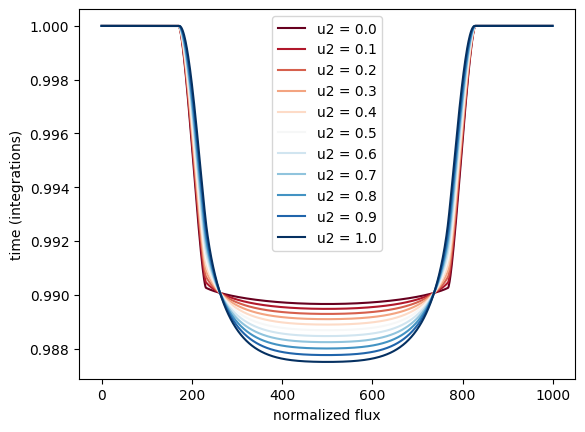

In [7]:
u1 = 0.1
u2 = np.linspace(0, 1, 11)
models = np.array([transit(t, (u1, u2), k, r) for u2 in u2])
[plt.plot(m, color=plt.cm.RdBu(u2), label='u2 = {:0.1f}'.format(u2)) for m, u2 in zip(models, u2)];
plt.legend()
plt.xlabel('normalized flux')
plt.ylabel('time (integrations)')

Text(0, 0.5, 'residuals (e-/s)')

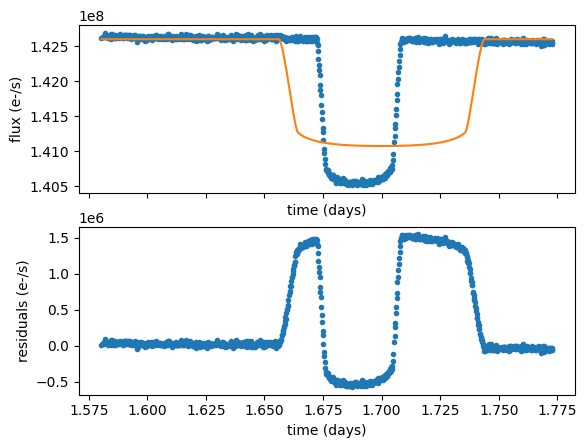

In [27]:
# now lets load up some data: 
time, flux, err = np.loadtxt('gj_1214_b_t1_nrs2.txt').T

# lets try to match it with a transit model:

ld = [0.1, 0.2]
k = [1.7, 5.0, 20.0, 90.0, 0.0, 0.0]
r = 0.1

fig, axs = plt.subplots(2, 1, sharex=True)
model = transit(time, ld, k, r) * 1.426e8
axs[0].plot(time, flux, '.')
axs[0].plot(time, model)
axs[0].set_xlabel('time (days)')
axs[0].set_ylabel('flux (e-/s)')

# and plot the residuals -- not bad! clearly not quite the right keplerian parameters though... 
axs[1].plot(time, flux - model, '.')
axs[1].set_xlabel('time (days)')
axs[1].set_ylabel('residuals (e-/s)')

In [28]:
# lets see if we can do better by actually fitting the model with scipy's minimize function 
from scipy.optimize import minimize

# first, we define a a cost function to minimize -- in this case the likelihood of the data given the model assuming white noise: 

def log_like(model_params, time, flux, err):
    
    r = model_params[0]
    
    # note that we're using the logarithm of the baseline flux as the 
    # input paramater. Sometimes this helps the fitting algorithm deal with large numbers. 
    f0 = np.exp(model_params[1])
    ld = model_params[2:4]
    k = model_params[4:]
    
    try:
        model = transit(time, ld, k, r) * f0
    except:
        return -np.inf
    return 0.5 * np.sum((flux - model)**2 / err**2)

initial_params = [0.116, np.log(1.426e8), 0.1, 0.2, 1.69, 1.58, 15.3, 90, 0.0, 0.0]
optimized_params = minimize(log_like, initial_params, args=(time, flux, err)).x

Text(0, 0.5, 'residuals (e-/s)')

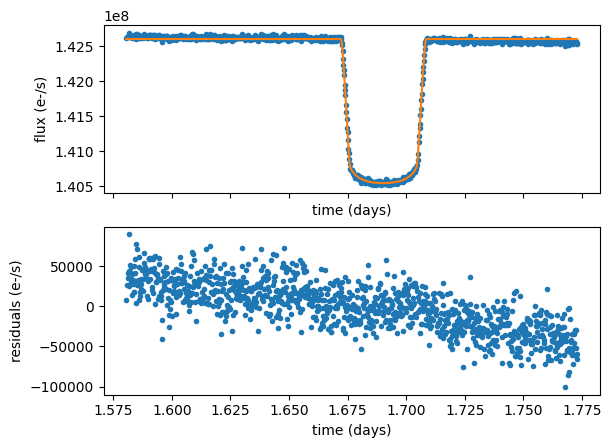

In [29]:
r = optimized_params[0]
log_f0 = optimized_params[1]
ld = optimized_params[2:4]
k = optimized_params[4:]

fig, axs = plt.subplots(2, 1, sharex=True)
model = transit(time, ld, k, r) * np.exp(log_f0)
axs[0].plot(time, flux, '.')
axs[0].plot(time, model)
axs[0].set_xlabel('time (days)')
axs[0].set_ylabel('flux (e-/s)')

# residuals look a lot better this time, but there's still an overall trend
axs[1].plot(time, flux - model, '.')
axs[1].set_xlabel('time (days)')
axs[1].set_ylabel('residuals (e-/s)')

Text(0, 0.5, 'residuals (e-/s)')

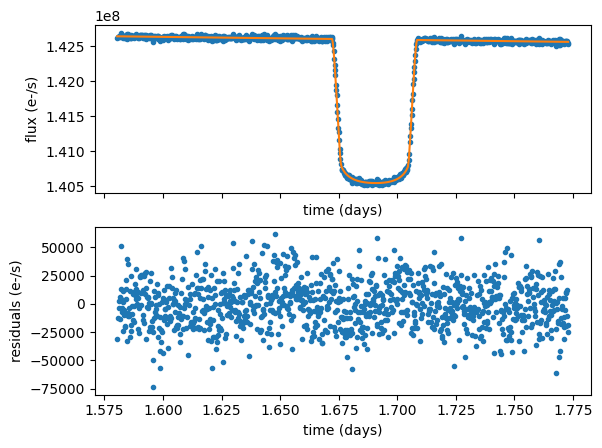

In [30]:
# let's add a systematics model to account for the trend. 

def systematics(time, a, b):
    
    return a + b * time 

def full_model(model_params, time):
    
    r = model_params[0]
    ld = model_params[1:3]
    k = model_params[3:-2]
    
    # now we're using the logarithm for both the baseline flux and the 
    # slope of the flux trend since both are expected to be large.
    log_a, log_b = model_params[-2:]
    
    transit_model = transit(time, ld, k, r)
    systematics_model = systematics(time, np.exp(log_a), -np.exp(log_b))
    return systematics_model * transit_model

def neg_log_like(model_params, time, flux, err):
    
    try:
        model = full_model(model_params, time)
        ll = 0.5 * np.sum((flux - model)**2 / err**2)
    except:
        return -np.inf
    
    if np.isfinite(ll):
        return ll
    else:
        return -np.inf

initial_params = [0.116, 0.1, 0.2, 1.69, 1.6, 14, 90, 0.0, 0.0, np.log(1.426e8), np.log(3.2e5)]
optimized_params = minimize(neg_log_like, initial_params, args=(time, flux, err)).x

fig, axs = plt.subplots(2, 1, sharex=True)
model = full_model(optimized_params, time)
axs[0].plot(time, flux, '.')
axs[0].plot(time, model)
axs[0].set_xlabel('time (days)')
axs[0].set_ylabel('flux (e-/s)')

# looks good now! The residuals are pretty much just Gaussian-distributed other than some outliers. 
axs[1].plot(time, flux - model, '.')
axs[1].set_xlabel('time (days)')
axs[1].set_ylabel('residuals (e-/s)')

100%|█| 10000/10000 


Text(0, 0.5, 'residuals (e-/s)')

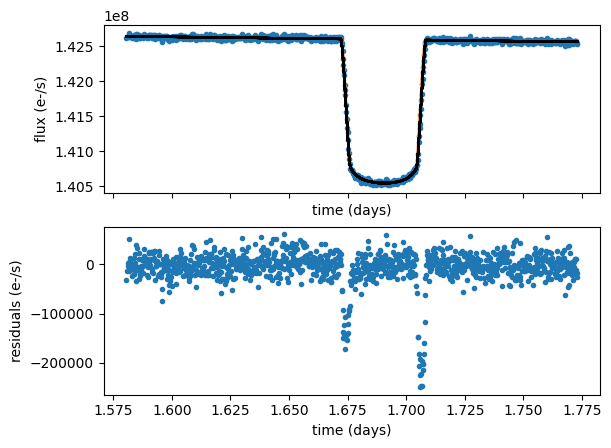

In [31]:
# but of course we don't just want the best-fit parameters, we want to know the uncertainties as well. 
# for that we need MCMC.
import emcee

log_like = lambda model_params, time, flux, err: -neg_log_like(model_params, time, flux, err)

init = optimized_params
pos = init + 1e-8 * np.random.randn(len(init)*2, len(init))
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_like, args=(time, flux, err)
)
sampler.run_mcmc(
    pos,
    10_000,
    progress=True, 
    skip_initial_state_check=True
);

fig, axs = plt.subplots(2, 1, sharex=True)

chains = sampler.get_chain()[5_000:, :, :]
mean_params = np.mean(chains, axis=(0, 1))
model = full_model(mean_params, time)

axs[0].plot(time, flux, '.')
axs[0].plot(time, model)
axs[0].set_xlabel('time (days)')
axs[0].set_ylabel('flux (e-/s)')

inds = np.random.randint(5_000, size=100)
flat_chains = np.concatenate(chains)
for i in inds:
    axs[0].plot(time, full_model(flat_chains[i], time), color='k')

axs[1].plot(time, flux - model, '.')
axs[1].set_xlabel('time (days)')
axs[1].set_ylabel('residuals (e-/s)')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (5000) than draws (22). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


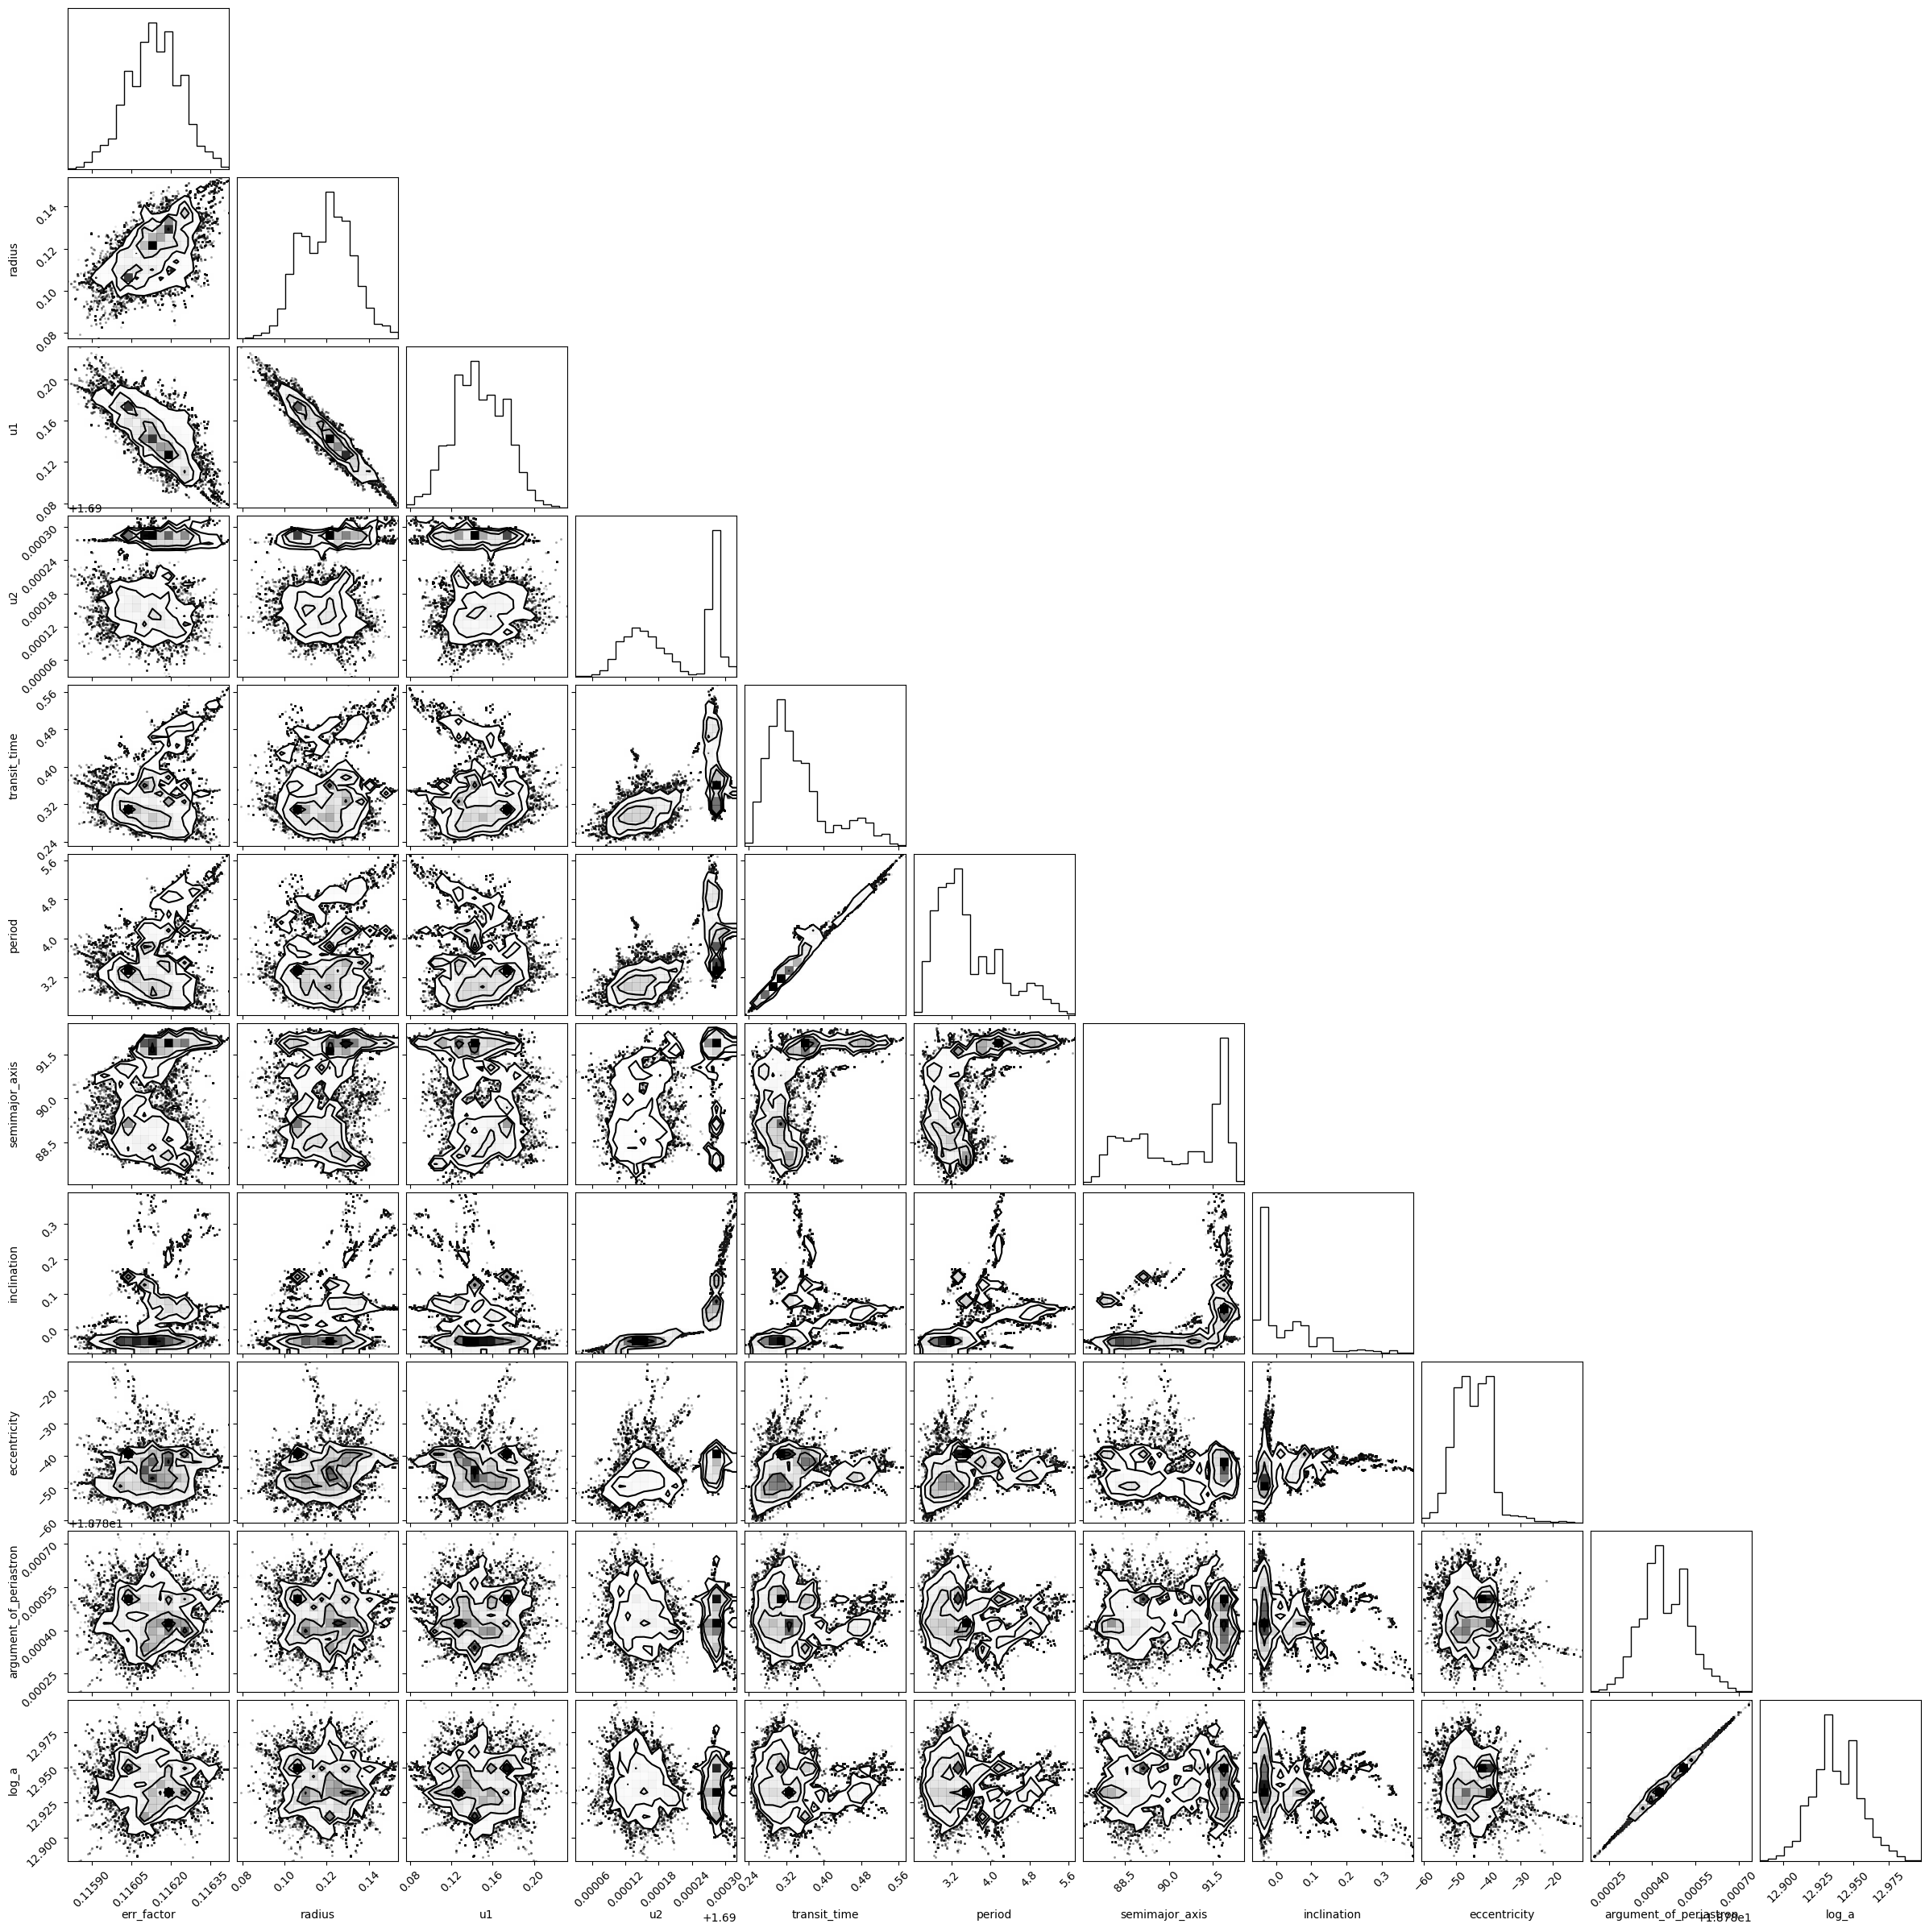

In [32]:
# we can visualize the posteriors with a corner plot
import corner
corner.corner(
    chains, 
    labels=[
        'err_factor', 'radius', 'u1', 'u2', 
        'transit_time', 'period', 
        'semimajor_axis', 'inclination', 
        'eccentricity', 'argument_of_periastron',
        'log_a', 'log_b'
    ]
);

100%|█| 20000/20000 


Text(0, 0.5, 'residuals (e-/s)')

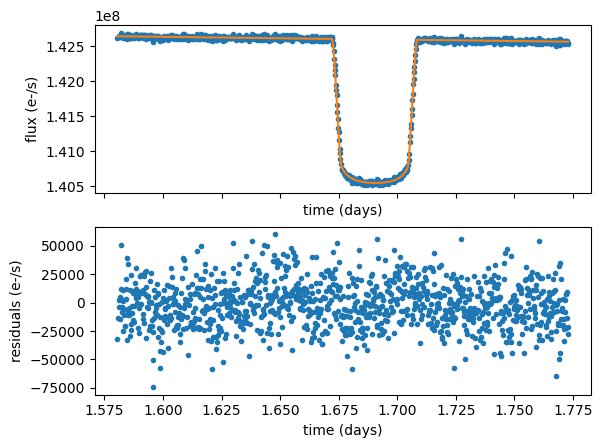

In [33]:
# Okay this looks fine, I guess, but there are a few things to note. 
# First, there's a really strong degeneracy between semimajor axis and period, 
# indicated by the highly correlated posterior samples. We know the period for 
# this planet, so there's no reason to be fitting for it. We should either 
# hold the period constant, or better yet place a prior on the period. 

def log_priors(model_params):
    
    r = model_params[0]
    ld = np.array(model_params[1:3])
    k = model_params[3:-2]
    log_a, log_b = model_params[-2:]
        
    transit_time, period, semimajor_axis, inclination, eccentricity, argument_of_periastron = k
    
    lp = 0
    
    # log of a gaussian centered at the true period +/- 1.8e-8 
    lp += -0.5 * (period - 1.580404531)**2 / (1.8e-8**2)
    # eccentricity should be between 0 and 1, but let's constrain it to be even smaller
    lp += -np.inf if (eccentricity < 0) | (eccentricity > 0.1) else 0
    # inclination should be less than 90 degrees 
    lp += -np.inf if (inclination > 90) else 0
    # and both limb-darkening parameters should be between 0 and 1
    lp += -np.inf if np.any(ld < 0) | np.any(ld > 1) else 0
    # and the argument of periastron should be between -180 and 180
    lp += -np.inf if (argument_of_periastron < -180) | (argument_of_periastron > 180) else 0
    
    return lp
    
def log_like(model_params, time, flux, err):
    ll = -neg_log_like(model_params, time, flux, err) + log_priors(model_params)
    if np.isnan(ll):
        print(model_params)
        return -np.inf
    else:
        return ll

#log_like = lambda model_params, time, flux, err: -neg_log_like(model_params, time, flux, err) + log_priors(model_params)

#optimized_params = minimize(lambda model_params, time, flux, err: -log_like(model_params, time, flux, err), optimized_params, args=(time, flux, err)).x

init = optimized_params
#init = [0.116, 0.1, 0.2, 1.69, 1.580404531, 15, 88.9, 0.001, 0.0, np.log(1.431e8), np.log(3.2e5)]
init[4] = 1.580404531
init[5] = 14
init[6] = 89.9 # make sure that the initial inclination is valid (not > 90, not < ~88)
init[7] = 0.001 # be careful not to put the eccentricity right on the boundary of the prior at 0.0

pos = init + 1e-6 * np.random.randn(len(init)*2, len(init))
nwalkers, ndim = pos.shape
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_like, args=(time, flux, err)
)
sampler.run_mcmc(
    pos,
    20_000,
    progress=True, 
    skip_initial_state_check=True
);

fig, axs = plt.subplots(2, 1, sharex=True)

chains = sampler.get_chain()[10_000:, :, :]
mean_params = np.mean(chains, axis=(0, 1))
model = full_model(mean_params, time)

axs[0].plot(time, flux, '.')
axs[0].plot(time, model)
axs[0].set_xlabel('time (days)')
axs[0].set_ylabel('flux (e-/s)')

#inds = np.random.randint(5_000, size=100)
#flat_chains = np.concatenate(chains)
#for i in inds:
#    axs[0].plot(time, full_model(flat_chains[i], time), color='k')

# looks good now! The residuals are pretty much just Gaussian-distributed other than some outliers. 
axs[1].plot(time, flux - model, '.')
axs[1].set_xlabel('time (days)')
axs[1].set_ylabel('residuals (e-/s)')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/arviz/data/base.py:272: UserWarning: More chains (10000) than draws (22). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


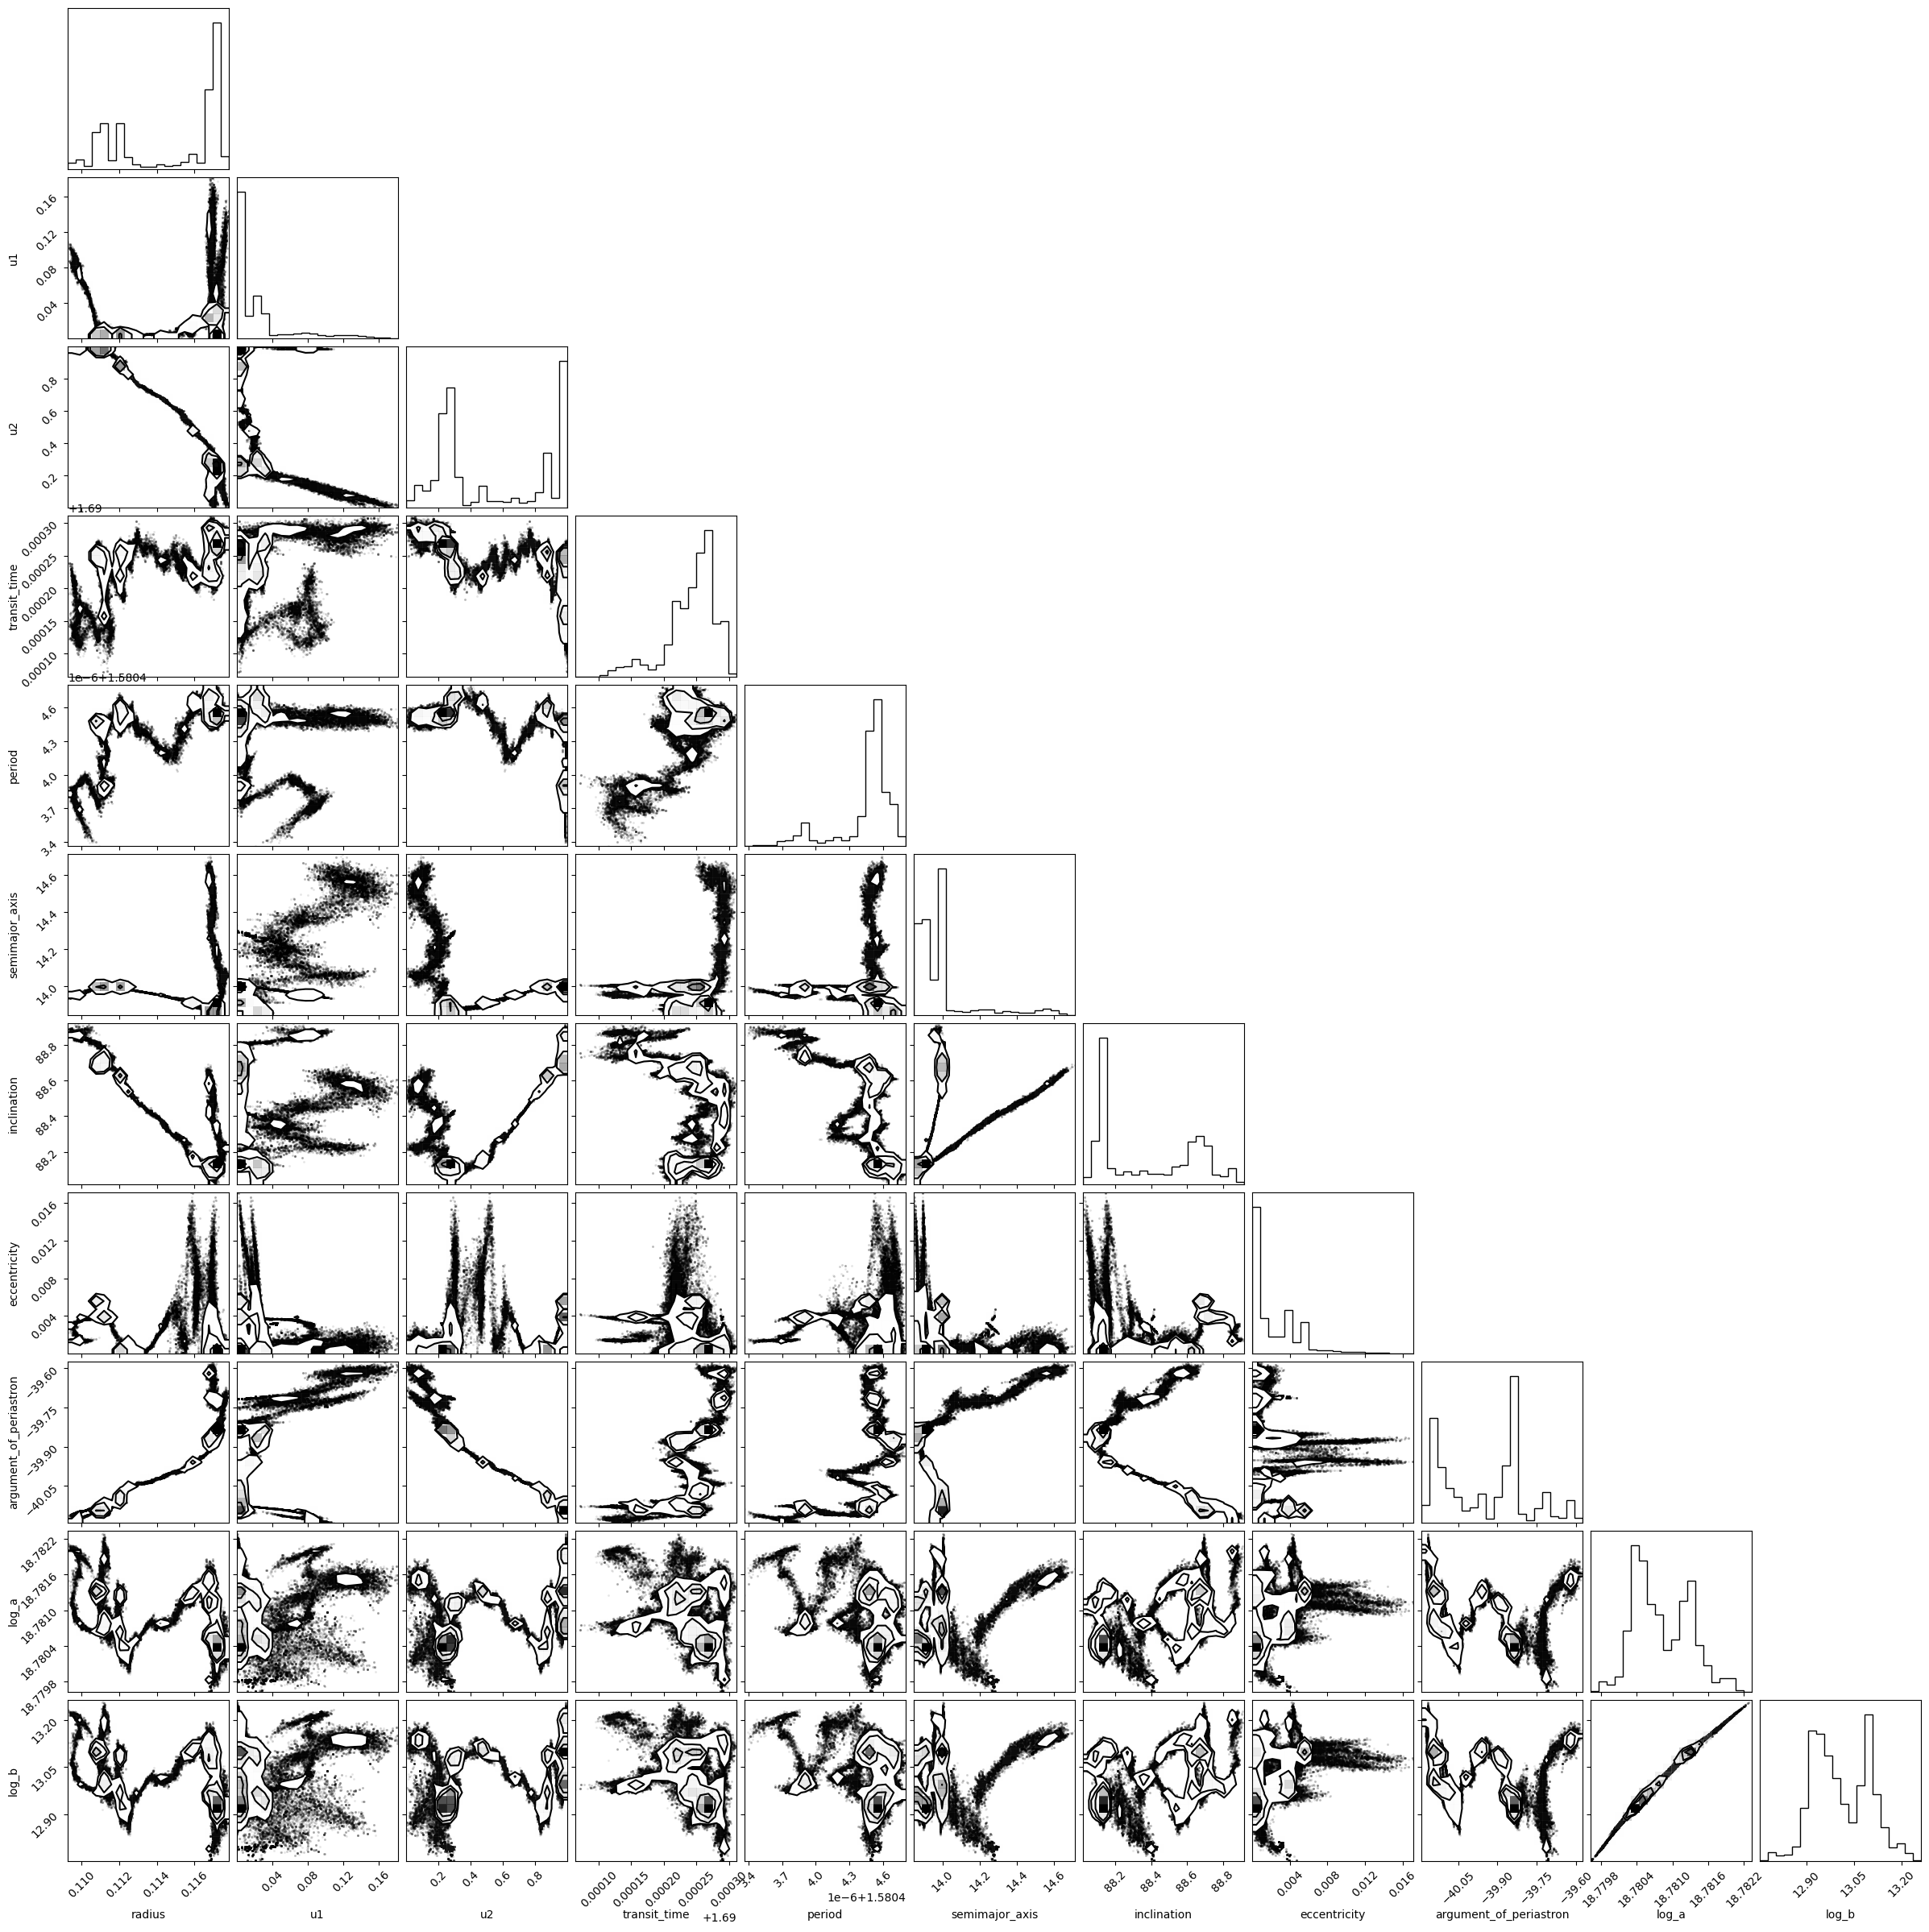

In [15]:
# we can visualize the posteriors with a corner plot
import corner
corner.corner(
    chains, 
    labels=[
        'radius', 'u1', 'u2', 
        'transit_time', 'period', 
        'semimajor_axis', 'inclination', 
        'eccentricity', 'argument_of_periastron',
        'log_a', 'log_b'
    ]
);

In [16]:
# This is looking a lot better, but notice that the eccentricity and the semimajor axis are still fairly poorly-constrained and 
# degenerate with each other. That may be okay if we truly don't have good constraints on either of those parameters, 
# but if we know for instance that the planet's orbit is close to circular, we can get a much better constraint on 
# the semimajor axis by constraining the eccentricity further. Let's go back and change the prior to on eccentricity to
# a gaussian centered at 0.002 with a standard deviation of 1e-3 and re-run the MCMC. 